In [5]:
refs = {
    '1995-2023' : '/code/data/aa_pnse_rst/rst_ba_1995_2023_bin.tif',
    '2024'      : '/code/data/aa_pnse_rst/rst_ba_2024_bin.tif'
}

perigos = {
    'dem'    : '/code/data/results_lri_pnse/lri_dem.tif',
    'slope'  : '/code/data/results_lri_pnse/lri_slope.tif',
    'aspect' : '/code/data/results_lri_pnse/lri_aspect.tif',
    'lulc'   : '/code/data/results_lri_pnse/lri_lulc.tif',
    'lri'    : '/code/data/results_lri_pnse/res_lri.tif',
    'prob'   : '/code/data/results_lri_pnse/wprobability.tif',
    'peri'   : '/code/data/results_lri_pnse/res_perigosity.tif'
}

val = 1

otbl = '/code/data/results_lri_pnse/valida_lri.xlsx'

In [6]:
import os
import pandas as pd
from glass.pys.oss import fprop, lst_ff
from glass.ete.perig.eval import pseudo_roc
from glass.wt import obj_to_tbl

In [7]:
ftbl = []

reflst = list(refs.keys())
for p in perigos:
    rname = fprop(perigos[p], "fn")
    row = [p, rname]
    for ref in reflst:
        vtbl, rauc, pseudo_auc = pseudo_roc(
            refs[ref], perigos[p], val,
            os.path.join(os.path.dirname(otbl), f'{p}_{rname}_{ref}.xlsx')
        )

        row.append(rauc)

    ftbl.append(row)

fdf = pd.DataFrame(ftbl, columns=['alias', 'perigosity'] + reflst)

obj_to_tbl(fdf, otbl)

/tmp/ipykernel_5963/200186345.py:8: DeprecationWarning: `round_` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `round` instead.
  vtbl, rauc, pseudo_auc = pseudo_roc(
/glass/glass/ete/perig/eval.py:37: RuntimeWarning: invalid value encountered in cast
  int_array = int_array.astype(np.int32)
/glass/glass/wt/__init__.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  row[c] = str(row[c])
/tmp/ipykernel_5963/200186345.py:8: DeprecationWarning: `round_` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `round` instead.
  vtbl, rauc, pseudo_auc = pseudo_roc(
/glass/glass/ete/perig/eval.py:37: RuntimeWarning: invalid value encountered in cast
  int_array = int_array.astype(np.int32)
/glass/glass/wt/__init__.py:23: FutureWarning: Setting an item of inco

'/code/data/results_lri_pnse/valida_lri.xlsx'

In [8]:
rauc

0.8641171735870578

In [9]:
vtbl

'/code/data/results_lri_pnse/peri_res_perigosity_2024.xlsx'

In [10]:
pseudo_auc

0.8641171735870575

In [11]:
vtbl, rauc, pseudo_auc = pseudo_roc(
    '/code/data/aa_pnse_rst/rst_ba_2024_bin.tif',
    '/code/data/results_lri_pnse/res_perigosity.tif',
    val
)

/tmp/ipykernel_5963/3093483382.py:1: DeprecationWarning: `round_` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `round` instead.
  vtbl, rauc, pseudo_auc = pseudo_roc(
/glass/glass/ete/perig/eval.py:37: RuntimeWarning: invalid value encountered in cast
  int_array = int_array.astype(np.int32)


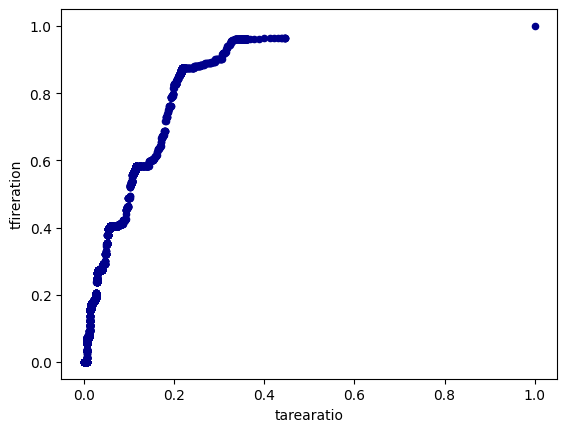

In [12]:
ax1 = vtbl.plot.scatter(x='tarearatio', y='tfireration',c='DarkBlue')

In [13]:
# Verificsr
fdf

,alias,perigosity,1995-2023,2024
0,dem,lri_dem,0.790203,0.709411
1,slope,lri_slope,0.776850,0.757951
2,aspect,lri_aspect,0.774835,0.728218
3,lulc,lri_lulc,0.791486,0.865523
4,lri,res_lri,0.797527,0.743805
5,prob,wprobability,0.823569,0.892295
6,peri,res_perigosity,0.821438,0.864117
